In [18]:
import zipfile
import pandas as pd
import os

# Open the zip file
with zipfile.ZipFile("./data/515_reviews.zip", "r") as zip_ref:
    # Extract the file to a temporary directory
    zip_ref.extractall("temp")

# Read the CSV file into a pandas DataFrame
papers = pd.read_csv("temp/Hotel_Reviews.csv")

# Print head
papers.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [19]:
# Remove the columns
papers = papers[['Positive_Review', 'Negative_Review']]

# Print out the first rows of papers
papers.head()

,Positive_Review,Negative_Review
0,Only the park outside of the hotel was beauti...,I am so angry that i made this post available...
1,No real complaints the hotel was great great ...,No Negative
2,Location was good and staff were ok It is cut...,Rooms are nice but for elderly a bit difficul...
3,Great location in nice surroundings the bar a...,My room was dirty and I was afraid to walk ba...
4,Amazing location and building Romantic setting,You When I booked with your company on line y...


In [20]:
# Load the regular expression library
import re

# Remove punctuation
papers['paper_text_processed'] = \
papers['Positive_Review'].map(lambda x: re.sub('[,\.!?]', '', x))

# Convert the titles to lowercase
papers['paper_text_processed'] = \
papers['paper_text_processed'].map(lambda x: x.lower())

# Print out the first rows of papers
papers['paper_text_processed'].head()

0     only the park outside of the hotel was beauti...
1     no real complaints the hotel was great great ...
2     location was good and staff were ok it is cut...
3     great location in nice surroundings the bar a...
4      amazing location and building romantic setting 
Name: paper_text_processed, dtype: object

In [21]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


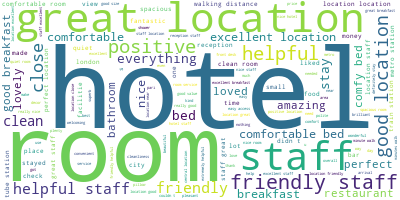

In [22]:
# Import the wordcloud library
from wordcloud import WordCloud

# Join the different processed titles together.
long_string = ','.join(list(papers['paper_text_processed'].values))

# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=1000, contour_width=3, contour_color='steelblue')

# Generate a word cloud
wordcloud.generate(long_string)

# Visualize the word cloud
wordcloud.to_image()

In [23]:
%pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [24]:
import gensim
from gensim.utils import simple_preprocess
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use'])

def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))

def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) 
             if word not in stop_words] for doc in texts]


data = papers.paper_text_processed.values.tolist()
data_words = list(sent_to_words(data))

# remove stop words
data_words = remove_stopwords(data_words)

print(data_words[:1][0][:30])

[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


['park', 'outside', 'hotel', 'beautiful']


In [25]:
import gensim.corpora as corpora

# Create Dictionary
id2word = corpora.Dictionary(data_words)

# Create Corpus
texts = data_words

# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]

# View
print(corpus[:1][0][:30])

[(0, 1), (1, 1), (2, 1), (3, 1)]


In [26]:
from pprint import pprint

# number of topics
num_topics = 3

# Build LDA model
lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                       id2word=id2word,
                                       num_topics=num_topics)

# Print the Keyword in the 10 topics
pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

[(0,
  '0.055*"staff" + 0.034*"room" + 0.028*"positive" + 0.025*"hotel" + '
  '0.025*"friendly" + 0.022*"bed" + 0.022*"helpful" + 0.021*"clean" + '
  '0.020*"breakfast" + 0.019*"comfortable"'),
 (1,
  '0.095*"location" + 0.052*"staff" + 0.050*"great" + 0.040*"good" + '
  '0.028*"breakfast" + 0.027*"friendly" + 0.026*"hotel" + 0.025*"room" + '
  '0.024*"excellent" + 0.021*"nice"'),
 (2,
  '0.028*"room" + 0.026*"hotel" + 0.018*"staff" + 0.015*"location" + '
  '0.013*"close" + 0.011*"good" + 0.010*"station" + 0.009*"clean" + '
  '0.009*"everything" + 0.008*"stay"')]


In [27]:
%pip install pyLDAvis

Note: you may need to restart the kernel to use updated packages.


In [28]:
import pyLDAvis.gensim_models as gensimvis
import pickle 
import pyLDAvis

# Visualize the topics
pyLDAvis.enable_notebook()

LDAvis_data_filepath = os.path.join('./results/ldavis_prepared_'+str(num_topics))

# # this is a bit time consuming - make the if statement True
# # if you want to execute visualization prep yourself
if 1 == 1:
    LDAvis_prepared = gensimvis.prepare(lda_model, corpus, id2word)
    with open(LDAvis_data_filepath, 'wb') as f:
        pickle.dump(LDAvis_prepared, f)

# load the pre-prepared pyLDAvis data from disk
with open(LDAvis_data_filepath, 'rb') as f:
    LDAvis_prepared = pickle.load(f)

pyLDAvis.save_html(LDAvis_prepared, './results/ldavis_prepared_'+ str(num_topics) +'.html')

LDAvis_prepared

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.066056  0.048095       1        1  42.670023
1      0.015955 -0.072692       2        1  29.352926
0     -0.082011  0.024597       3        1  27.977052, topic_info=           Term           Freq          Total Category  logprob  loglift
24     location  171128.000000  171128.000000  Default  30.0000  30.0000
21        great   95957.000000   95957.000000  Default  29.0000  29.0000
95     positive   39453.000000   39453.000000  Default  28.0000  28.0000
47        staff  189573.000000  189573.000000  Default  27.0000  27.0000
91     friendly   81883.000000   81883.000000  Default  26.0000  26.0000
..          ...            ...            ...      ...      ...      ...
87        quiet    6441.586523   20802.911244   Topic3  -5.3689   0.1015
326  everything    7112.299829   28775.634522   Topic3  -5.2698  -0.1239
173        like    5045.746877   11808.269821   Topic3  -5.6131   0.4235
17    excellent    6230.153345   58438.693622   Topic3  -5.4023  -0.9648
21        great    6531.469219   95957.125283   Topic3  -5.3550  -1.4135

[303 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
960       1  0.180696      air
960       2  0.040124      air
960       3  0.779234      air
928       1  0.914056  airport
928       2  0.071602  airport
...     ...       ...      ...
136       2  0.178899   within
136       3  0.053177   within
57        1  0.563206    would
57        2  0.278757    would
57        3  0.158034    would

[612 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 2, 1])

In [ ]:
docnum = 3

print(papers['Positive_Review'][docnum])
print(doc_lda[docnum])

 Great location in nice surroundings the bar and restaurant are nice and have a lovely outdoor area The building also has quite some character 
[(0, np.float32(0.028922232)), (1, np.float32(0.94366884)), (2, np.float32(0.02740894))]


In [ ]:
lda_model.show_topic(1)

[('location', np.float32(0.09468408)),
 ('staff', np.float32(0.052286364)),
 ('great', np.float32(0.04950924)),
 ('good', np.float32(0.040251475)),
 ('breakfast', np.float32(0.028117457)),
 ('friendly', np.float32(0.026615834)),
 ('hotel', np.float32(0.026051596)),
 ('room', np.float32(0.025354134)),
 ('excellent', np.float32(0.023883933)),
 ('nice', np.float32(0.020965353))]

: 